# Practica 04: Ánalisis de Datos Exploratorio con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa de estudios:** Ingenieria en Entornos virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026 

### Unidad 2: Preparación de los Datos 

**Nombre del Estudiante:** Erandy Belen Morales Mendoza \
**Matrícula:** 230188 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #0000FF 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;">🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)</h1> 
<p style="color: #C76E00; font-size: 1.1em; margin-top: 10px;"> Predicción de Precisos • Análisis de Categorias • Ingeniería de Funcionalidades • Comparación de Modelos</p>
</div>

---

## 📋 Tabla de Contenidos

| #  | Sección | Descripción |
|----|----------|-------------|
| 1  | [Instalaciones & Carga de Datos](#s1) | Librerías, carga del CSV y exploración inicial de la estructura de los datos. |
| 2  | [Diccionario de Datos](#s2) | Explicación del contenido de las columnas y cálculo del porcentaje de datos faltantes. |
| 3  | [Limpieza de Datos](#s3) | Aplicación de métodos básicos de limpieza (eliminación de duplicados, tratamiento de datos nulos y agrupación). |
| 4  | [Ingeniería de Características](#s4) | Creación y transformación de variables para mejorar el análisis y el desempeño de los modelos. |
| 5  | [Análisis Univariado](#s5) | Estudio individual de las variables mediante estadísticas descriptivas y visualizaciones. |
| 6  | [Análisis de Categorías](#s6) | Exploración y comparación de las variables categóricas presentes en el conjunto de datos. |
| 7  | [Análisis de Disponibilidad](#s7) | Evaluación del estado de disponibilidad de los productos y su distribución. |
| 8  | [Correlación y Análisis Bivariado](#s8) | Análisis de relaciones entre variables y evaluación de asociaciones significativas. |
| 9  | [Prueba de Hipótesis Estadística](#s9) | Aplicación de pruebas estadísticas para validar supuestos y diferencias entre grupos. |
| 10 | [Definición de Problemas de Aprendizaje Automático](#s10) | Identificación del problema de Machine Learning, variables objetivo y enfoque de modelado. |
| 11 | [Marco de Selección de Modelos](#s11) | Comparación de diferentes modelos de regresión y criterios para seleccionar el más adecuado. |
| 12 | [Modelos de Regresión: Predicción del Precio de Amazon](#s12) | Entrenamiento y evaluación de modelos para predecir precios de productos en Amazon. |
| 13 | [Ajuste de Hiperparámetros](#s13) | Optimización de modelos mediante técnicas de búsqueda de hiperparámetros como GridSearchCV. |
| 14 | [Comparación y Selección de Modelos](#s14) | Comparación del desempeño de los modelos entrenados y selección del modelo final basado en métricas de evaluación. |
| 15 | [Información Clave e Informe de Negocios](#s15) | Presentación de hallazgos relevantes, conclusiones de negocio y recomendaciones estratégicas basadas en el análisis realizado. |


## 1. Instalaciones & Carga de Datos 🔧 <a id='s1'></a>

<div style="background:#f8f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India listas de Productos - 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [4]:
# ============================================================
# SECTION 1 - Setup & Data Loading
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
#ML -  Machine Learning- Entrenamiento de modelos matematicos para predecir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler


print(f'✅ Pandas :{pd.__version__}')
print(f'✅ Numpy :{pd.__version__}')
print('✅ Todas las librerias cargaron con éxito!')

✅ Pandas :2.3.3
✅ Numpy :2.3.3
✅ Todas las librerias cargaron con éxito!


In [5]:
# Cargar dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f'📦 Shape: {df_raw.shape}')
print(f'📋 Columns: {df_raw.columns.tolist()}')

df_raw.head(3)

📦 Shape: (1448, 17)
📋 Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.Diccionario de Datos del Data Frame <a id='s2'></a>

In [6]:
# Diccionario de columnas
col_info = {
    'rl'                : 'URL del Producto en Amazon.in',
    'asin'              : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'              : 'Nombre o Título del Producto',
    'overview'          : 'Breve reseña del Producto (mayoría vacío [])',
    'price'             : 'Precio como string (e.g. "1,600.00")',
    'currency'          : 'Código de Divisa (todas en INR)',
    'availability'      : 'Texto del estado del Stock (Inventario)',
    'brand'             : 'Nombre de la Marca/Autor',
    'about_item'        : 'Detalles/Especificaciones (mayoría faltante)',
    'img_source'        : 'URLs de Imágenes del Producto',
    'description'       : 'Descripción detallada y completa (mayoría faltante)',
    'specifications'    : 'Especificaciones Técnicas',
    'primary_category'  : 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'        : 'Subcategoría de nivel 1',
    'category_2'        : 'Subcategoría de nivel 2',
    'category_3'        : 'Subcategoría de nivel 3',
    'breadcrumbs'       : 'Ruta de Categorías',
}

print('📖 Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100

    print(
        f'{col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
    )

📖 Diccionario por columnas:
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
name                 | Nombre o Título del Producto                  | Missing: 1%
overview             | Breve reseña del Producto (mayoría vacío [])  | Missing: 0%
price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
currency             | Código de Divisa (todas en INR)               | Missing: 24%
availability         | Texto del estado del Stock (Inventario)       | Missing: 33%
brand                | Nombre de la Marca/Autor                      | Missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
img_source           | URLs de Imágenes del Producto                 | Missing: 1%
description          | Descripción detallada y completa (mayoría fal | Missing: 92%
specifications       | Especificaciones Técnicas      

## 3. Limpieza de Datos <a id='s3'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color:#0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [7]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,096 / 1,448 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 607, 'Unknown': 482, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 81, 'Other': 25, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


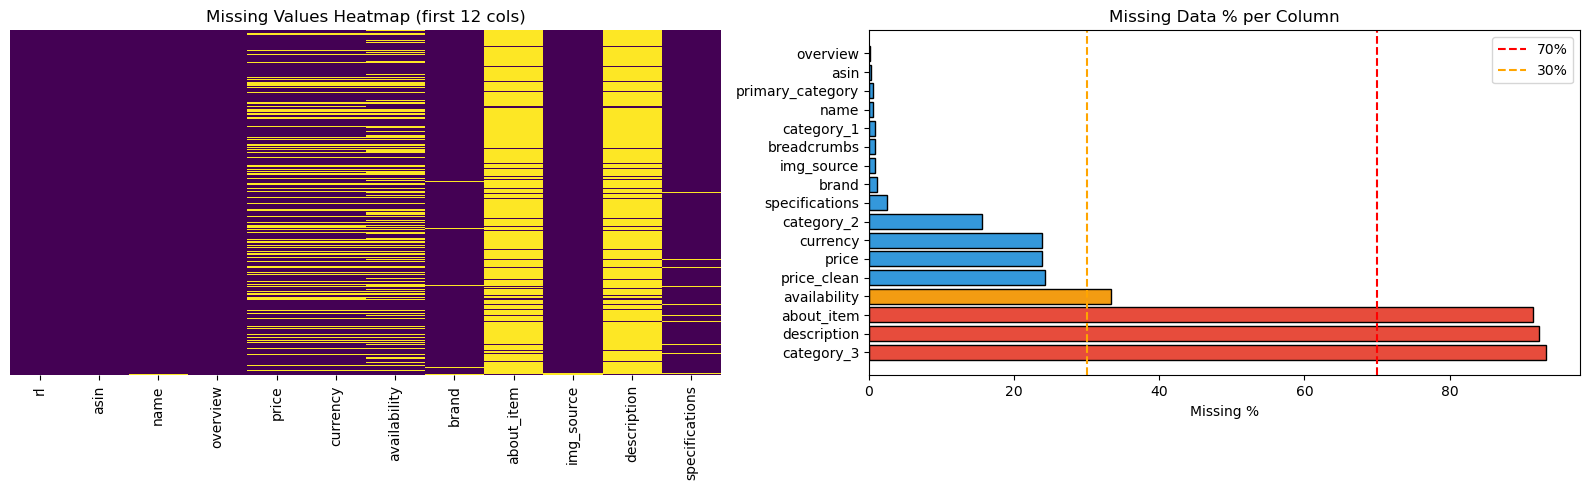

                  Missing Count  Missing Pct
category_3                 1351         93.3
description                1336         92.3
about_item                 1325         91.5
availability                482         33.3
price_clean                 352         24.3
price                       346         23.9
currency                    346         23.9
category_2                  226         15.6
specifications               36          2.5
brand                        16          1.1
img_source                   11          0.8
breadcrumbs                  12          0.8
category_1                   11          0.8
name                          8          0.6
primary_category              7          0.5
asin                          4          0.3
overview                      2          0.1


In [8]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())


## 4. Ingenieria de Caracteristicas (Feature Engineering)


<div style="background: #f0fff0; padding: 12px; border-left: 4px solid #27ae60; border-radius: 5px; color: #0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no soloutiliza los metros cuadrados brutos, sino que tambien considera la ubicación,la antogüedad y el estado. Nosotros hacemos lo mismo: extraemos informacion mas valiosa del texto sin procesar y las categorías..
</div>

In [9]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     105
2_low        287
3_mid        319
4_premium    259
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis univariado (Univariate Analysis)

<div style="background: #f0fff0; padding: 12px; border-left: 4px solid #27ae60; border-radius: 5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de los precios? ¿Existen valores atípicos (outliers)? ¿Los datos presentan algún tipo de sesgo?
</div>

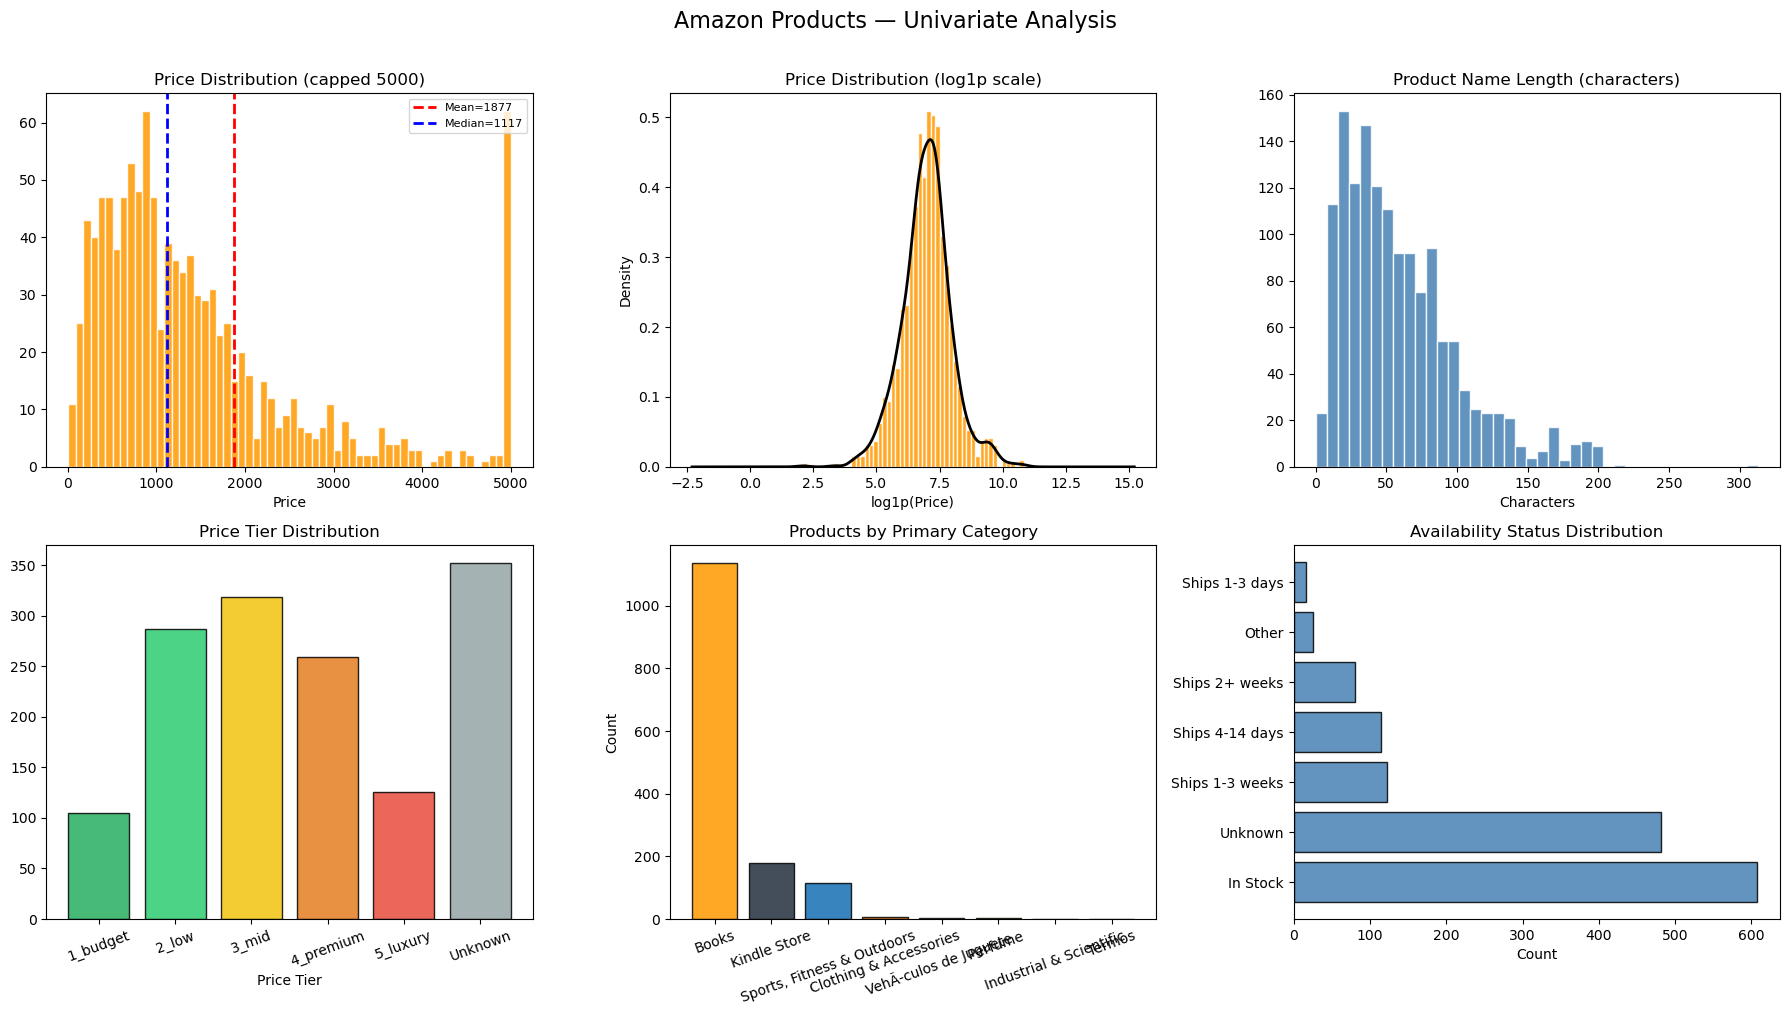

Shapiro-Wilk (log price, n=500)
Statistic = 0.9857
P-value = 0.000081
Price is still non-normal after log transform

Price Statistics:
count     1089.00
mean      1876.55
std       3337.35
min          7.00
25%        609.00
50%       1117.00
75%       1849.00
max      50555.00
Name: price_clean, dtype: float64


In [10]:
# ============================================================
# IMPORTS NECESARIOS
# ============================================================
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================

df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Mean={df_priced["price_clean"].mean():.0f}'
)

axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Median={df_priced["price_clean"].median():.0f}'
)

axes[0,0].set_title('Price Distribution (capped 5000)')
axes[0,0].set_xlabel('Price')
axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(
    ax=axes[0,1],
    color='black',
    lw=2
)

axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price)')

# Name length
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()

tier_colors = [
    '#27ae60',
    '#2ecc71',
    '#f1c40f',
    '#e67e22',
    '#e74c3c',
    '#95a5a6'
]

axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier')
axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()

axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()

axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# NORMALITY TEST
# ============================================================

sample_size = min(500, len(df_priced))

stat, p = shapiro(
    df_priced['log_price'].sample(
        sample_size,
        random_state=42
    )
)

print(f'Shapiro-Wilk (log price, n={sample_size})')
print(f'Statistic = {stat:.4f}')
print(f'P-value = {p:.6f}')

if p > 0.05:
    print('Price is normally distributed after log transform')
else:
    print('Price is still non-normal after log transform')

print('\nPrice Statistics:')
print(df_priced['price_clean'].describe().round(2))

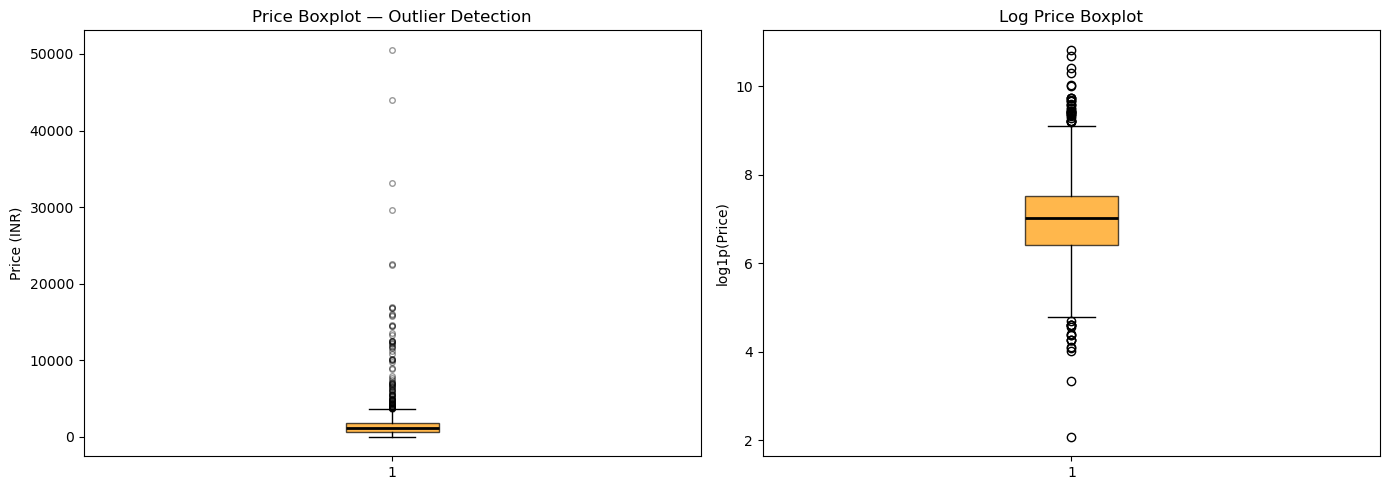

IQR method outliers: 93 (8.5%)
Price range (non-outlier): ₹-1251 – ₹3709

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [11]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))


## 6.Análisis de categoría 🗂️

<div style="background: #fff8dc; padding: 12px; border-left: 4px solid #f1c40f; border-radius: 5px; color: #996600;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra el mayor valor dentro de los productos?
</div>

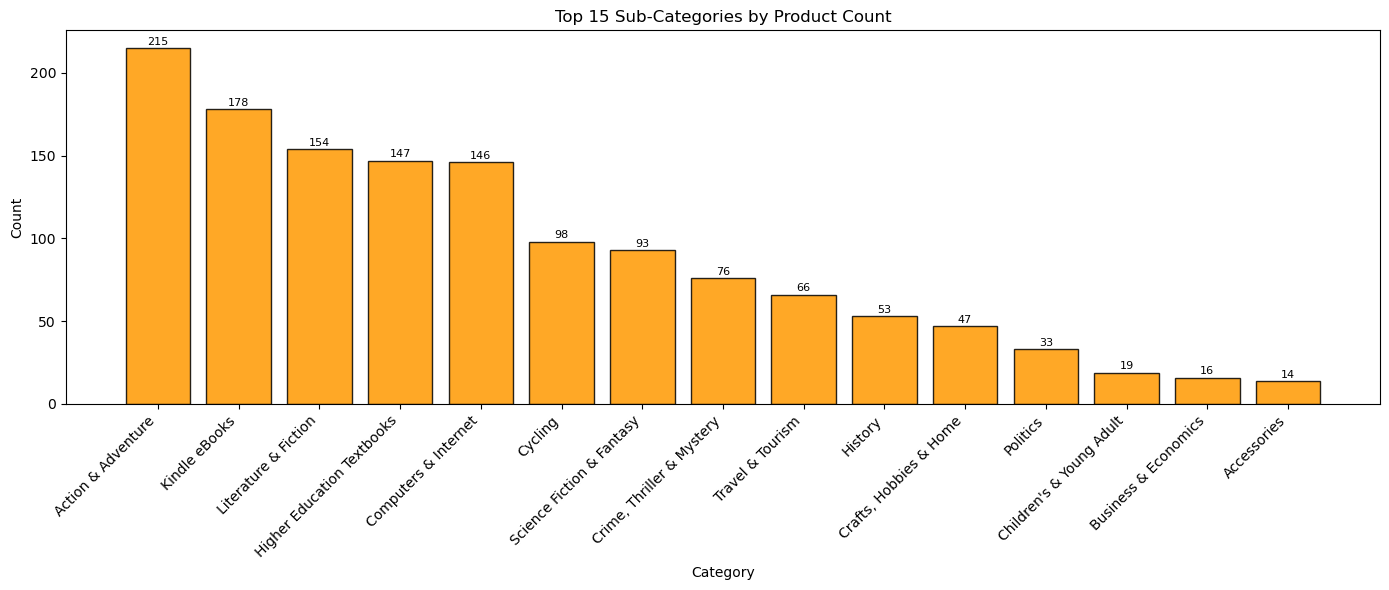

In [12]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

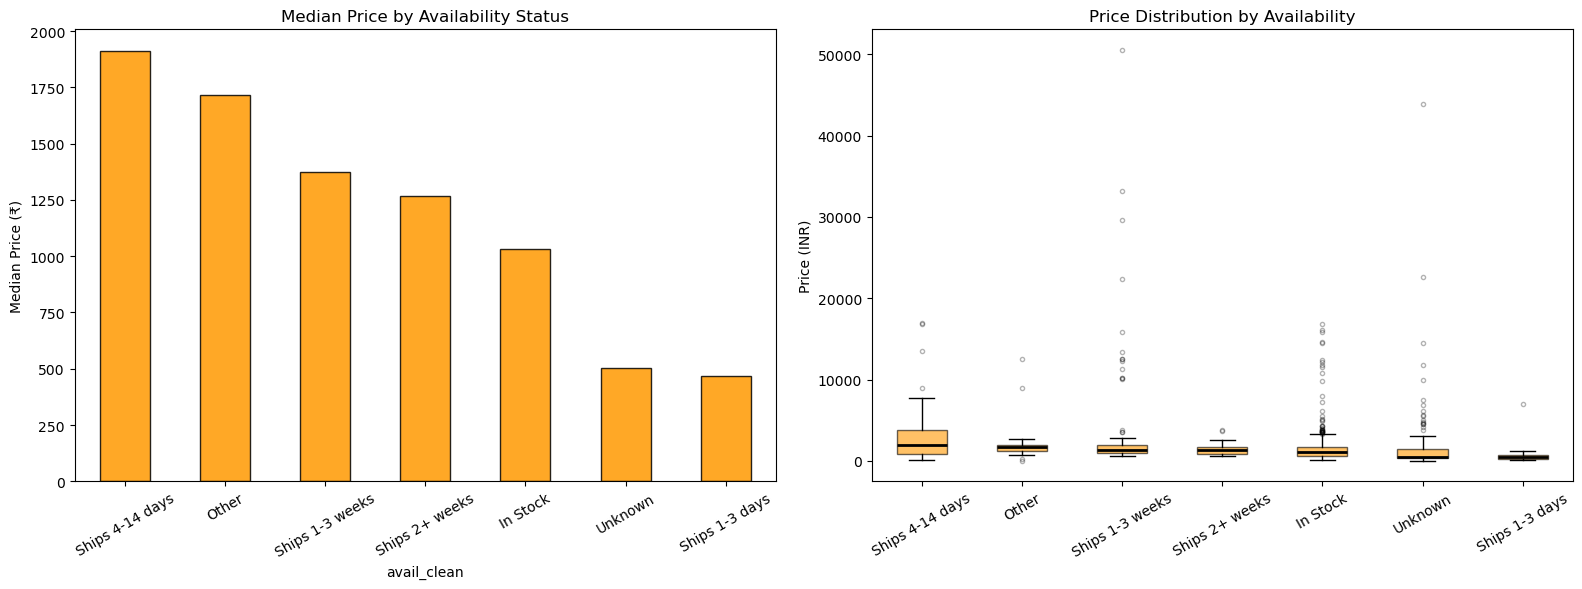

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1718.0  2343.6     21
Ships 1-3 weeks  1376.0  3209.7    122
Ships 2+ weeks   1267.0  1378.2     81
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [13]:
# Price by availability status
avail_price = (
    df_priced.groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------------
# Median Price by Availability
# -----------------------------------
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=30)

# -----------------------------------
# Boxplot Price Distribution
# -----------------------------------
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,  # ← CORRECCIÓN
    patch_artist=True,
    medianprops=dict(
        color='black',
        lw=2
    ),
    flierprops=dict(
        marker='o',
        markersize=3,
        alpha=0.3
    )
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Price by availability:')
print(avail_price.to_string())

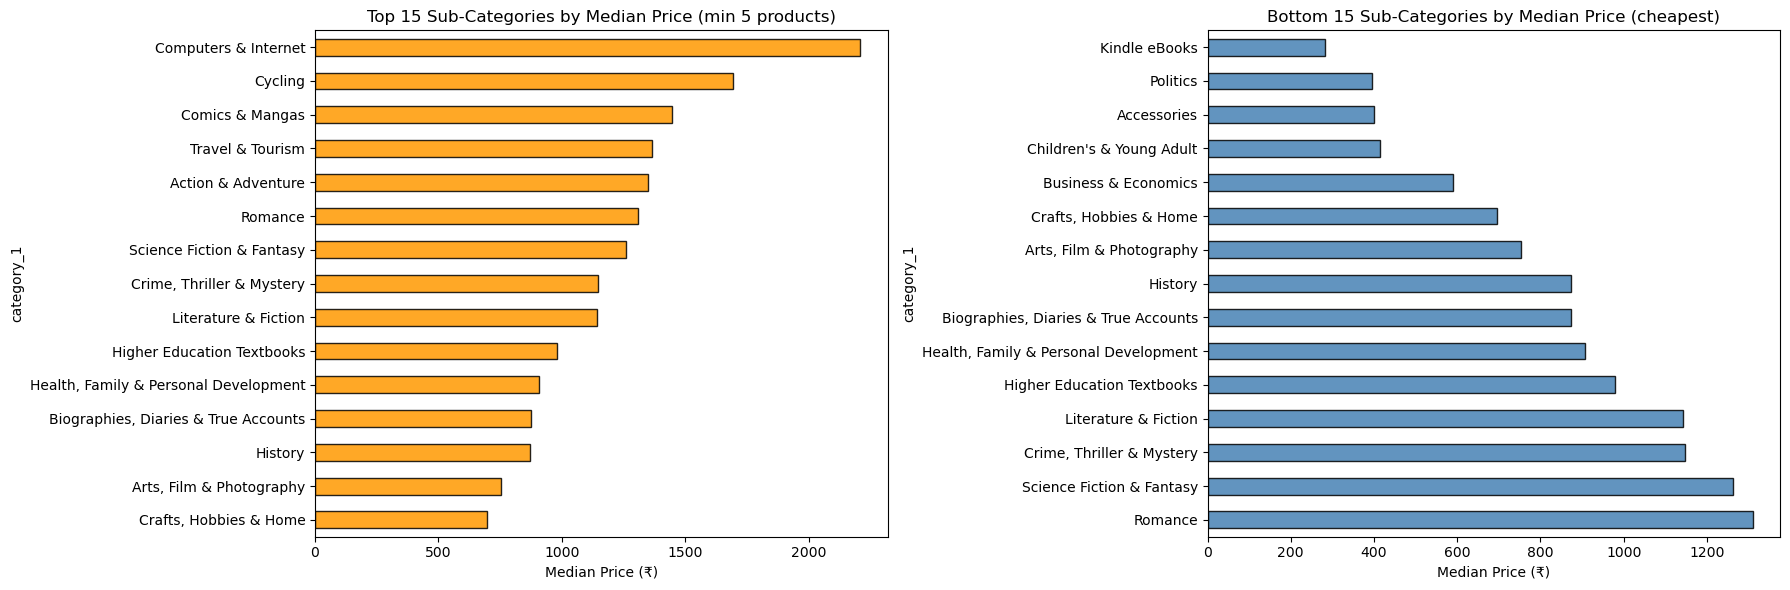

In [14]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7. Análisis de disponibilidad 📦

<div style="background: #ffe4ec; padding: 12px; border-left: 4px solid #ff69b4; border-radius: 5px; color: #c2185b;">
<b>Pregunta clave:</b> ¿El estado de disponibilidad influye en el precio? ¿Los productos premium tienen una mayor probabilidad de estar agotados?
</div>

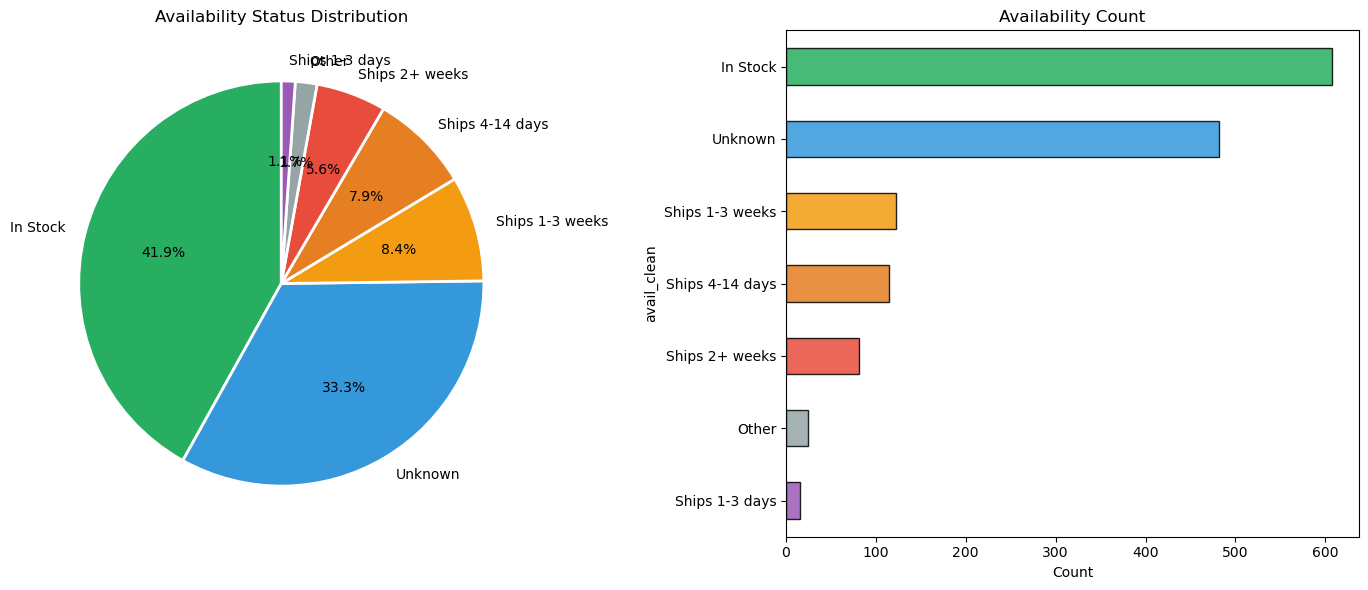

In [15]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

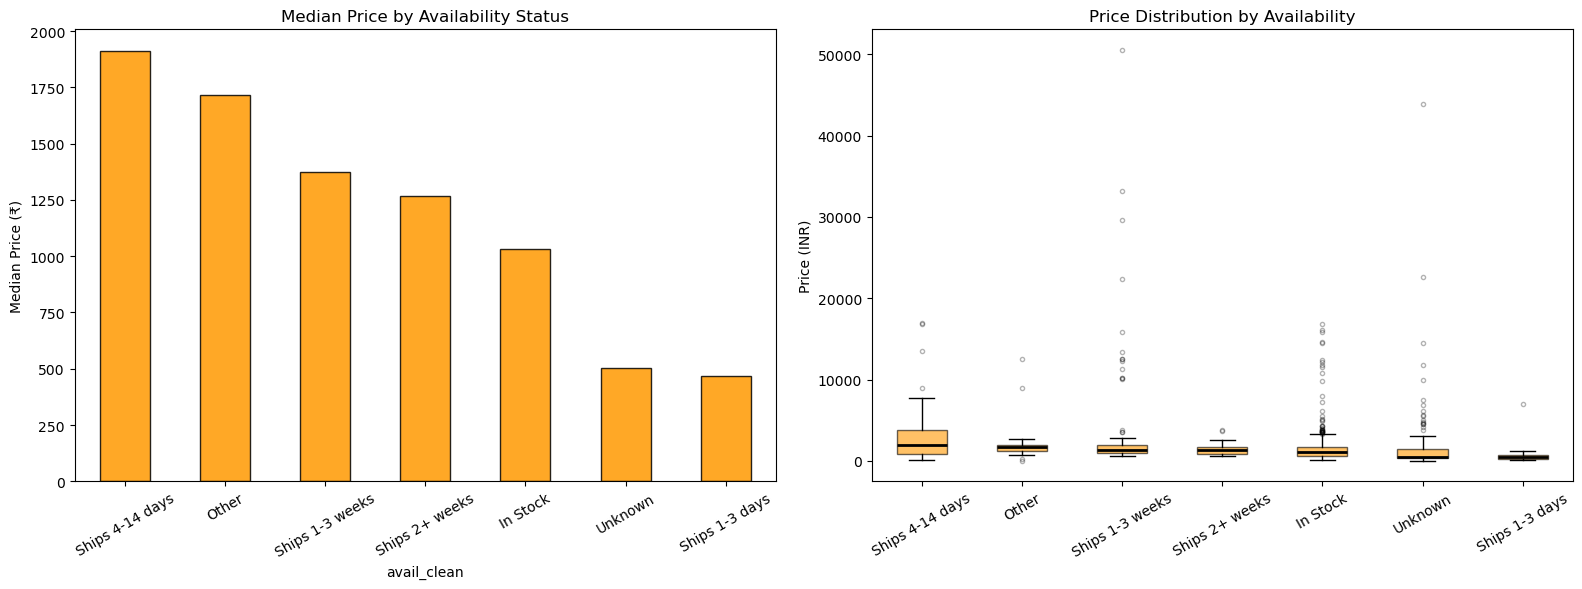

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1718.0  2343.6     21
Ships 1-3 weeks  1376.0  3209.7    122
Ships 2+ weeks   1267.0  1378.2     81
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [16]:
# Price by availability status
avail_price = (
    df_priced.groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

avail_price = avail_price[
    avail_price['count'] >= 5
].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=30)

# Boxplot
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,  # ← cambio aquí
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Price by availability:')
print(avail_price.to_string())

## 8. Correlación y análisis bivariado 🔗

<div style="background: #e6f7ff; padding: 12px; border-left: 4px solid #4fc3f7; border-radius: 5px; color: #0277bd;">
<b>Pregunta clave:</b> ¿Qué características presentan la mayor correlación con el precio? ¿La longitud del nombre del producto puede predecir su precio?
</div>

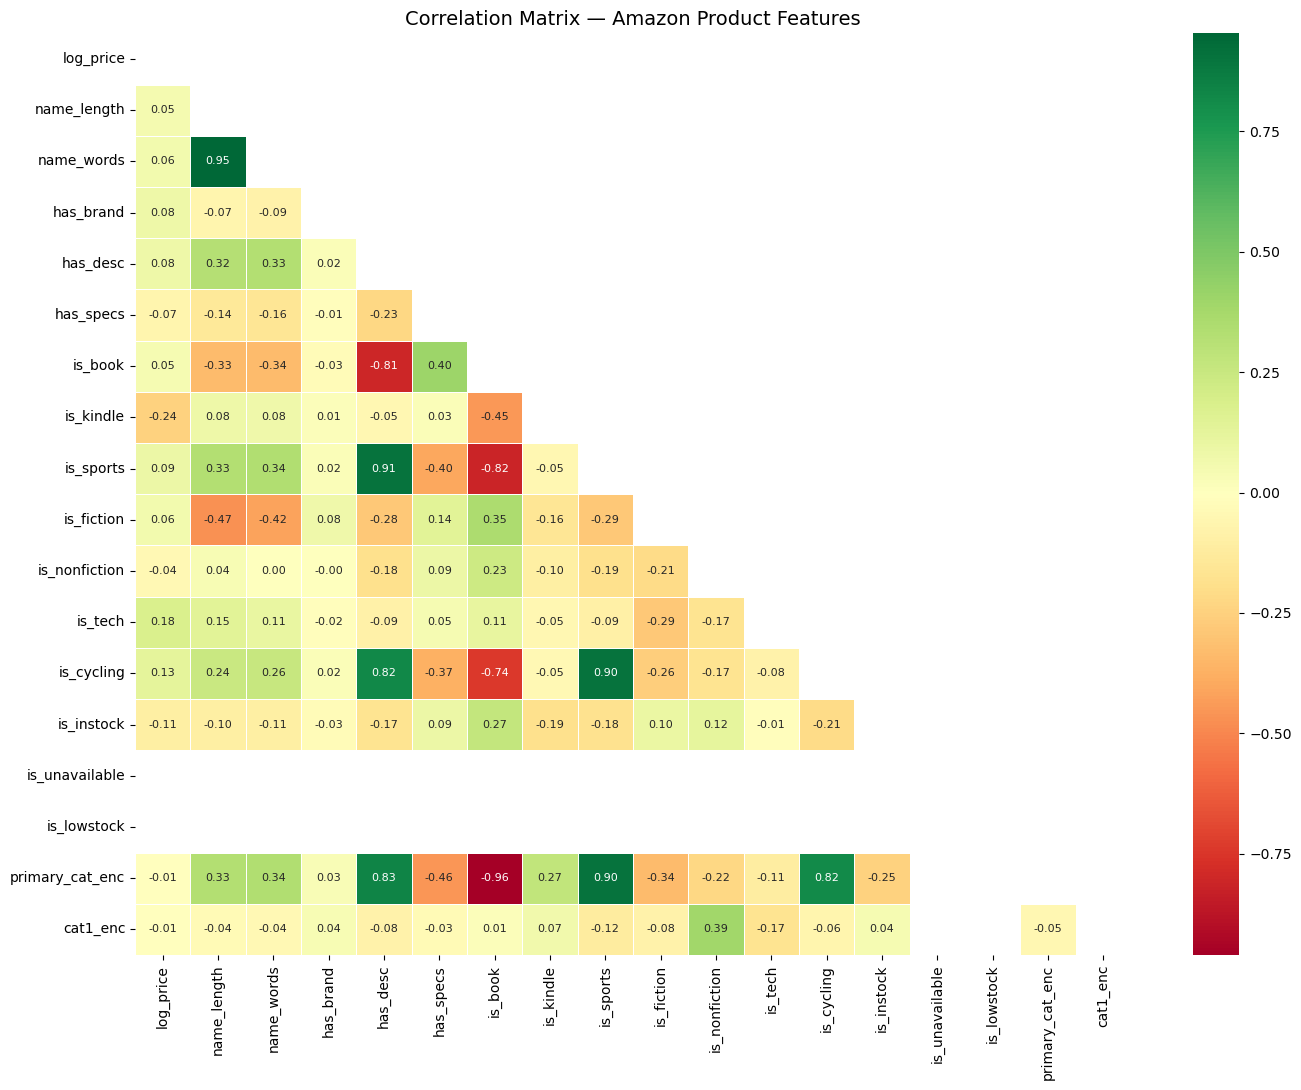

Top correlations with log_price:
is_tech            0.177110
is_cycling         0.127293
is_sports          0.092761
has_brand          0.082855
has_desc           0.081814
name_words         0.059818
is_fiction         0.057156
name_length        0.054528
is_book            0.047430
cat1_enc          -0.006069
primary_cat_enc   -0.007535
is_nonfiction     -0.041075
has_specs         -0.065704
is_instock        -0.107495
is_kindle         -0.244249
is_unavailable          NaN
is_lowstock             NaN


In [17]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

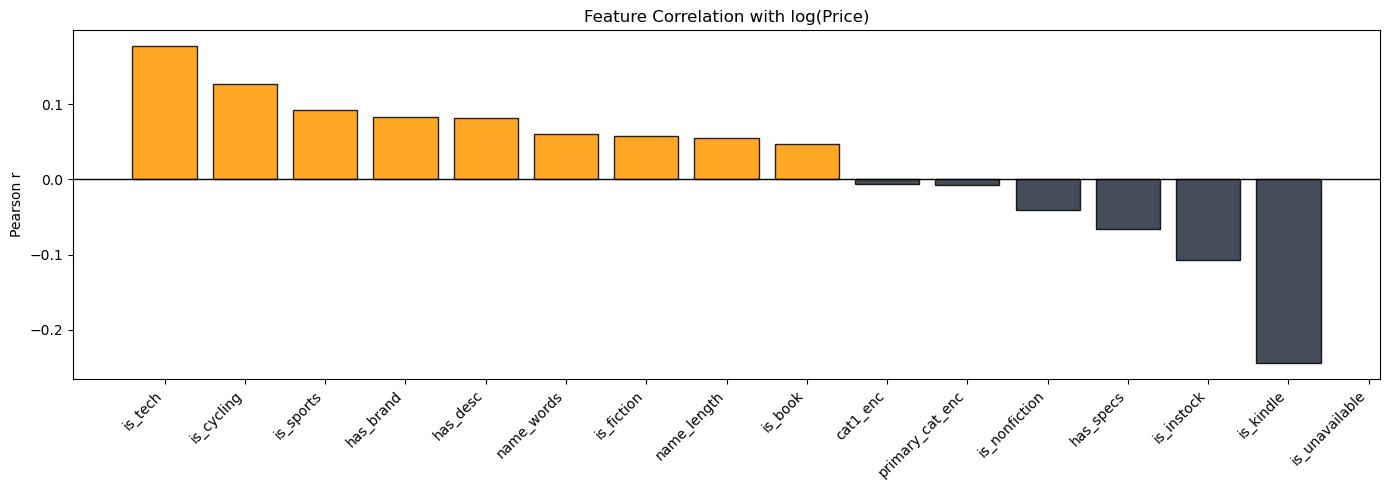

In [18]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

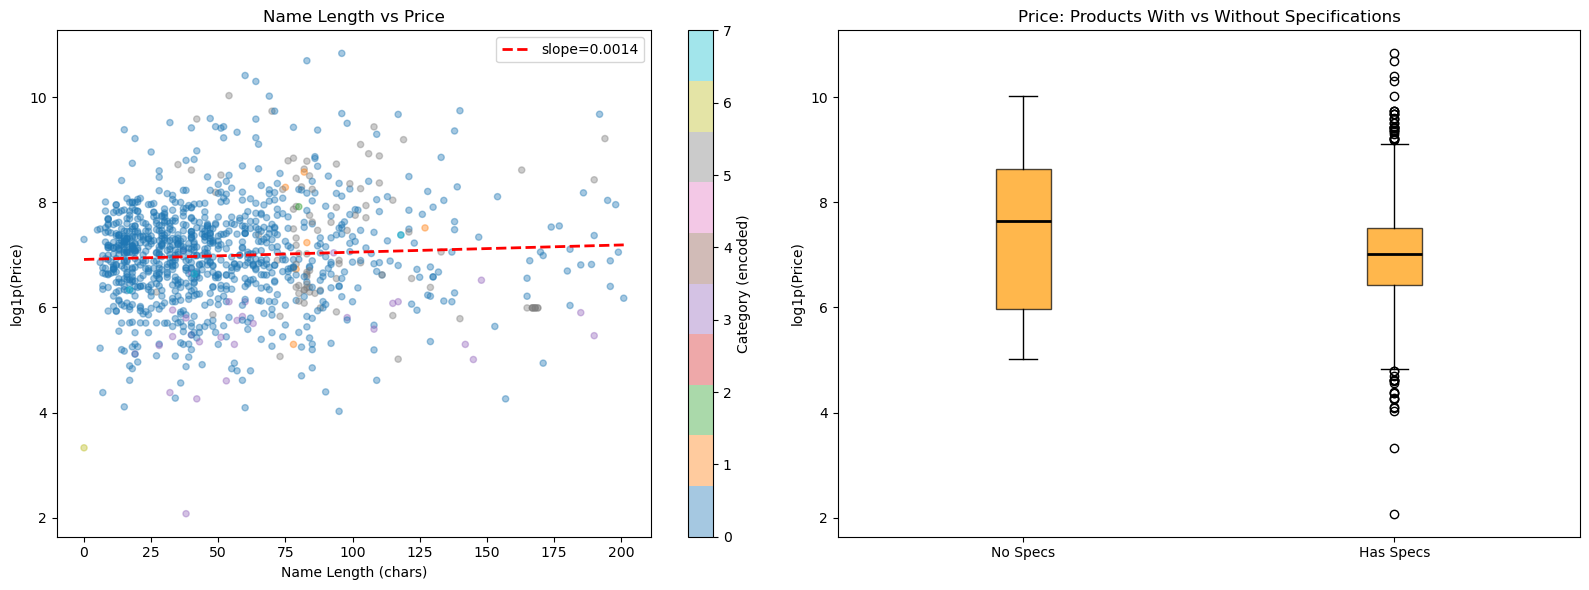

In [19]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------------
# Name Length vs Price
# -----------------------------------
sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

plt.colorbar(sc, ax=axes[0], label='Category (encoded)')

# Línea de tendencia
m, b = np.polyfit(
    df_priced['name_length'],
    df_priced['log_price'],
    1
)

x = np.linspace(
    0,
    df_priced['name_length'].max(),
    100
)

axes[0].plot(
    x,
    m * x + b,
    'r--',
    lw=2,
    label=f'slope={m:.4f}'
)

axes[0].set_xlabel('Name Length (chars)')
axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price')
axes[0].legend()

# -----------------------------------
# Price by Specifications
# -----------------------------------
axes[1].boxplot(
    [
        np.log1p(
            df_priced[df_priced['has_specs'] == 0]['price_clean']
        ),
        np.log1p(
            df_priced[df_priced['has_specs'] == 1]['price_clean']
        )
    ],
    tick_labels=['No Specs', 'Has Specs'],  # <-- CORRECCIÓN
    patch_artist=True,
    boxprops=dict(
        facecolor='#FF9900',
        alpha=0.7
    ),
    medianprops=dict(
        color='black',
        lw=2
    )
)

axes[1].set_title(
    'Price: Products With vs Without Specifications'
)
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout()
plt.show()

### 9. Prueba de hipótesis estadística 🧪

<div style="background: #F8F3E5; padding: 12px; border-left: 4px solid #E74C3C; border-radius: 5px; color: #0066D0;">
<b>Utilizamos pruebas no paramétricas:</b> <b>Kruskal-Wallis</b> y <b>Mann-Whitney U</b> porque el precio presenta una distribución altamente sesgada y no normal. α = 0.05.
</div>

<table style="width:100%; border-collapse: collapse; font-family: Arial, sans-serif;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid #ddd; padding: 8px;">#</th>
            <th style="border: 1px solid #ddd; padding: 8px;">Hipótesis</th>
            <th style="border: 1px solid #ddd; padding: 8px;">Prueba Estadística</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid #ddd; padding: 8px;"><b>H1</b></td>
            <td style="border: 1px solid #ddd; padding: 8px;">El precio difiere significativamente entre las categorías principales.</td>
            <td style="border: 1px solid #ddd; padding: 8px;">Kruskal-Wallis</td>
        </tr>
        <tr>
            <td style="border: 1px solid #ddd; padding: 8px;"><b>H2</b></td>
            <td style="border: 1px solid #ddd; padding: 8px;">Los libros tienen precios significativamente menores que los productos deportivos.</td>
            <td style="border: 1px solid #ddd; padding: 8px;">Mann-Whitney U</td>
        </tr>
        <tr>
            <td style="border: 1px solid #ddd; padding: 8px;"><b>H3</b></td>
            <td style="border: 1px solid #ddd; padding: 8px;">Los productos disponibles en stock tienen precios diferentes a los no disponibles.</td>
            <td style="border: 1px solid #ddd; padding: 8px;">Mann-Whitney U</td>
        </tr>
        <tr>
            <td style="border: 1px solid #ddd; padding: 8px;"><b>H4</b></td>
            <td style="border: 1px solid #ddd; padding: 8px;">La longitud del nombre del producto está positivamente correlacionada con el precio.</td>
            <td style="border: 1px solid #ddd; padding: 8px;">Correlación de Spearman</td>
        </tr>
        <tr>
            <td style="border: 1px solid #ddd; padding: 8px;"><b>H5</b></td>
            <td style="border: 1px solid #ddd; padding: 8px;">Los productos con especificaciones tienen precios más altos.</td>
            <td style="border: 1px solid #ddd; padding: 8px;">Mann-Whitney U</td>
        </tr>
    </tbody>
</table>

In [20]:
# ============================================================
# IMPORTS
# ============================================================

from scipy.stats import kruskal, mannwhitneyu, spearmanr

# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================

alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(
        a.dropna(),
        b.dropna(),
        alternative='two-sided'
    )

    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()

    return p

# ============================================================
# H1: Price across Primary Categories — Kruskal-Wallis
# ============================================================

cat_groups_kw = [
    df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
    for c in df_priced['primary_category'].unique()
    if len(df_priced[df_priced['primary_category'] == c]) >= 5
]

cat_labels_kw = [
    c for c in df_priced['primary_category'].unique()
    if len(df_priced[df_priced['primary_category'] == c]) >= 5
]

h1, p1 = kruskal(*cat_groups_kw)

print('H1: Price across Primary Categories — Kruskal-Wallis')

for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, median=₹{g.median():.0f}')

print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# ============================================================
# H2: Books vs Sports
# ============================================================

p2 = mw_test(
    'H2: Books vs Sports Products Price',
    df_priced[df_priced['is_book'] == 1]['price_clean'],
    df_priced[df_priced['is_sports'] == 1]['price_clean'],
    'Books',
    'Sports'
)

# ============================================================
# H3: In Stock vs Unavailable
# ============================================================

p3 = mw_test(
    'H3: In-Stock vs Unavailable Price',
    df_priced[df_priced['is_instock'] == 1]['price_clean'],
    df_priced[df_priced['is_unavailable'] == 1]['price_clean'],
    'In Stock',
    'Unavailable'
)

# ============================================================
# H4: Name Length vs Price — Spearman
# ============================================================

rho4, p4 = spearmanr(
    df_priced['name_length'],
    df_priced['price_clean']
)

print('H4: Name Length vs Price — Spearman Correlation')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# ============================================================
# H5: Products With vs Without Specifications
# ============================================================

p5 = mw_test(
    'H5: Products With vs Without Specifications',
    df_priced[df_priced['has_specs'] == 1]['price_clean'],
    df_priced[df_priced['has_specs'] == 0]['price_clean'],
    'Has Specs',
    'No Specs'
)


H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=955, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.8663, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=955, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  In Stock: n=599, median=₹1030
  Unavailable: n=0, median=₹nan
  Mann-Whitney U=nan, p=nan
  RESULT: ❌ FAIL TO REJECT H0.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0376, p=0.214524
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1065, median=₹1116
  No Specs: n=24, median=₹2169
  Mann-Whitney U=10830, p=0.200857
  RESULT: ❌ FAIL TO REJECT H0.



C:\Users\PC-10\AppData\Local\Temp\ipykernel_15988\182712300.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u, p = mannwhitneyu(


C:\Users\PC-10\AppData\Local\Temp\ipykernel_15988\4087654027.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
C:\Users\PC-10\AppData\Local\Temp\ipykernel_15988\4087654027.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
C:\Users\PC-10\AppData\Local\Temp\ipykernel_15988\4087654027.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
C:\Users\PC-10\AppData\Local\Temp\ipykernel_15988\4087654027.py:4

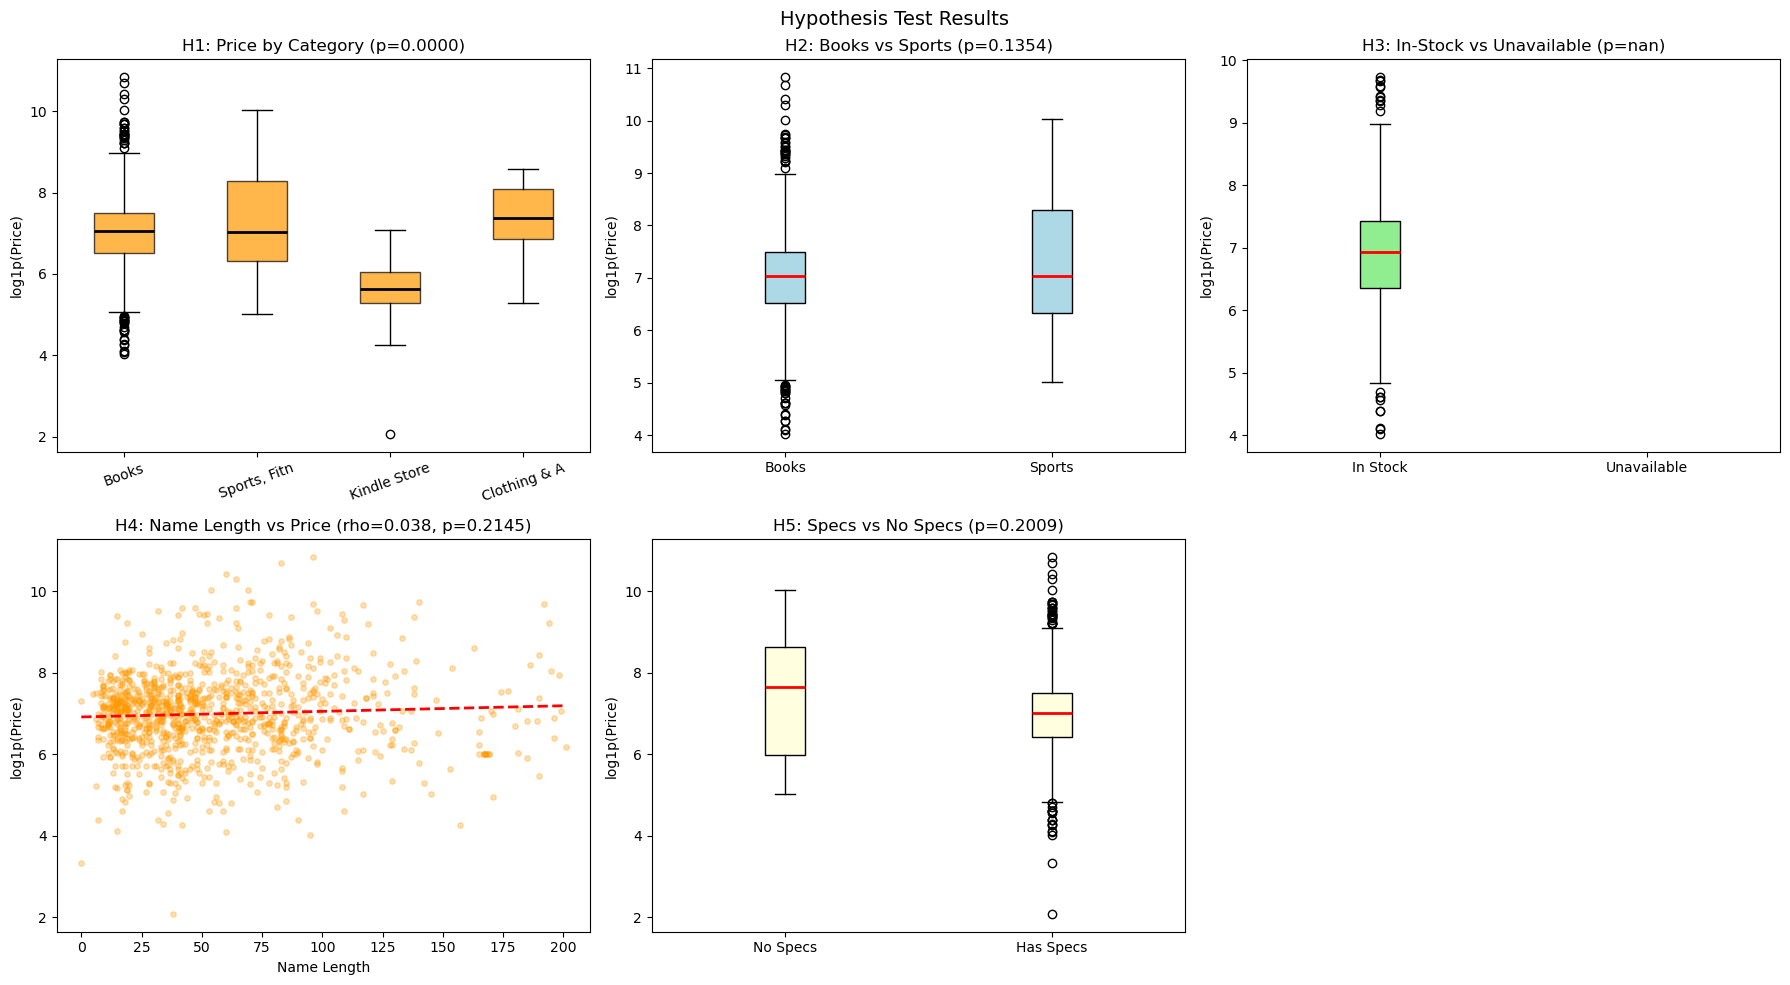

In [21]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Price by Category (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Price)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  labels=['Books','Sports'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Books vs Sports (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Price)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  labels=['In Stock','Unavailable'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: In-Stock vs Unavailable (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Price)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Name Length'); axes[1,0].set_ylabel('log1p(Price)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  labels=['No Specs','Has Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Specs vs No Specs (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Price)')

axes[1,2].set_visible(False)
plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout(); plt.show()

### 10. Definición de problemas de aprendizaje automático 🎯

<div style="background: #E8EEF5; padding: 12px; border-left: 4px solid #42A5F5; border-radius: 5px; color: #0066D0;">
<b>Tarea:</b> Predecir el precio del producto (escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y las características del producto.<br><br>

<b>¿Por qué utilizar una transformación logarítmica?</b> La distribución del precio presenta una fuerte asimetría hacia la derecha. La transformación logarítmica ayuda a normalizar los datos y evita que los valores atípicos muy elevados dominen la función de pérdida.
</div>

✅ ML dataset shape : (1089, 20)
✅ Features         : 18

Train: 871 | Test: 218


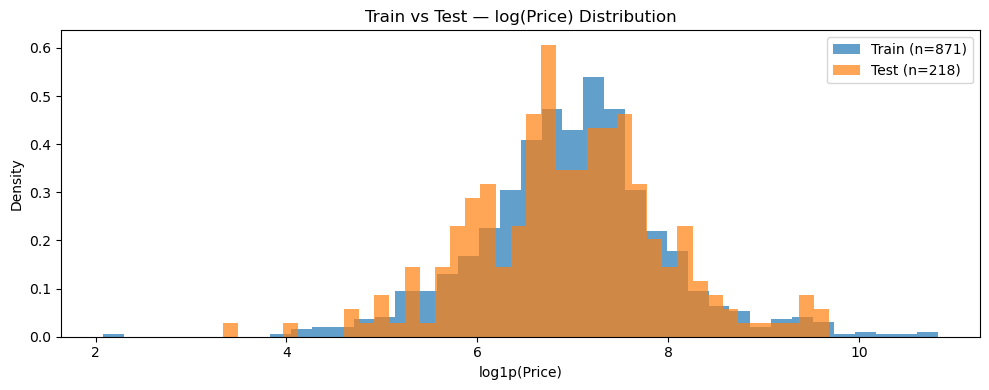

✅ Distributions look similar — good split!


In [22]:
# ============================================================
# IMPORTS
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================

FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

# Create ML dataset
df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features         : {len(FEATURE_COLS)}')

# Features and target
X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardization
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# ============================================================
# Visualize split
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    alpha=0.7,
    label=f'Train (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    alpha=0.7,
    label=f'Test (n={len(y_test)})',
    density=True
)

ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Distributions look similar — good split!')

### 11. Marco de selección de modelos 🧠

| Modelo             | Fortalezas                              | Debilidades                             | Mejor para                  |
|--------------------|-----------------------------------------|-----------------------------------------|-----------------------------|
| Regresión Lineal   | Rápida e interpretable                  | Asume linealidad                        | Modelo base                |
| Regresión Ridge    | Maneja la multicolinealidad             | Sigue siendo lineal                     | Variables correlacionadas  |
| Regresión Lasso    | Selección de características integrada  | Puede eliminar variables útiles         | Variables dispersas        |
| Bosque Aleatorio   | No lineal y robusto                     | Menos interpretable                     | Patrones complejos         |
| XGBoost / GBM      | Mayor precisión                         | Requiere ajuste de hiperparámetros      | Datos tabulares            |

La imagen presenta un marco de selección de modelos de aprendizaje automático que compara diferentes algoritmos de regresión, destacando sus ventajas, desventajas y aplicaciones recomendadas. Además, muestra las métricas utilizadas para evaluar el rendimiento de los modelos, como MAE, RMSE y R², las cuales permiten medir la precisión y capacidad predictiva de cada algoritmo. El objetivo es identificar el modelo que ofrezca el mejor equilibrio entre precisión, interpretación y desempeño para resolver el problema planteado.

### Métricas de Evaluación

- **MAE (Error Absoluto Medio)** — Error absoluto medio en escala logarítmica (*menor = mejor*).
- **RMSE (Raíz del Error Cuadrático Medio)** — Penaliza más los errores grandes.
- **R² (Coeficiente de Determinación)** — Mide la varianza explicada (*mayor = mejor*, máximo = 1.0).
- **MAE (₹)** — Convertido nuevamente a rupias indias (INR) para una interpretación de negocio más clara.

In [23]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')

✅ Evaluation helpers ready.


## 12. Modelos de regresión: predicción del precio de Amazon 💰
Entrenamos cinco modelos y los comparamos utilizando el mismo conjunto de prueba.

In [25]:
# ============================================================
# IMPORT LIBRARIES FOR MODELLING
# ============================================================

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Tree-Based Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost available")
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed. Using Gradient Boosting instead.")

XGBoost not installed. Using Gradient Boosting instead.


In [26]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================

print('='*60)
print('TRAINING ALL MODELS')
print('='*60)

# ------------------------------------------------------------
# 1. Linear Regression
# ------------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train_s, y_train)

lr_pred = eval_model(
    'Linear Regression',
    y_test,
    lr.predict(X_test_s)
)

# ------------------------------------------------------------
# 2. Ridge Regression
# ------------------------------------------------------------
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)

ridge_pred = eval_model(
    'Ridge Regression',
    y_test,
    ridge.predict(X_test_s)
)

# ------------------------------------------------------------
# 3. Lasso Regression
# ------------------------------------------------------------
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)

lasso_pred = eval_model(
    'Lasso Regression',
    y_test,
    lasso.predict(X_test_s)
)

# ------------------------------------------------------------
# 4. Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = eval_model(
    'Random Forest',
    y_test,
    rf.predict(X_test)
)

# ------------------------------------------------------------
# 5. XGBoost / Gradient Boosting
# ------------------------------------------------------------
if XGB_AVAILABLE:

    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

    xgb_model.fit(X_train, y_train)

    xgb_pred = eval_model(
        'XGBoost',
        y_test,
        xgb_model.predict(X_test)
    )

else:

    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )

    gbm.fit(X_train, y_train)

    xgb_pred = eval_model(
        'Gradient Boosting',
        y_test,
        gbm.predict(X_test)
    )

TRAINING ALL MODELS
  📊 Linear Regression:
     MAE (log)  = 0.7483  |  MAE (₹) = ₹1,201
     RMSE (log) = 0.9913  |  R²      = 0.0332
  📊 Ridge Regression:
     MAE (log)  = 0.7451  |  MAE (₹) = ₹1,194
     RMSE (log) = 0.9876  |  R²      = 0.0404
  📊 Lasso Regression:
     MAE (log)  = 0.7376  |  MAE (₹) = ₹1,168
     RMSE (log) = 0.9783  |  R²      = 0.0584
  📊 Random Forest:
     MAE (log)  = 0.6807  |  MAE (₹) = ₹1,090
     RMSE (log) = 0.9072  |  R²      = 0.1903
  📊 Gradient Boosting:
     MAE (log)  = 0.7054  |  MAE (₹) = ₹1,121
     RMSE (log) = 0.9351  |  R²      = 0.1396


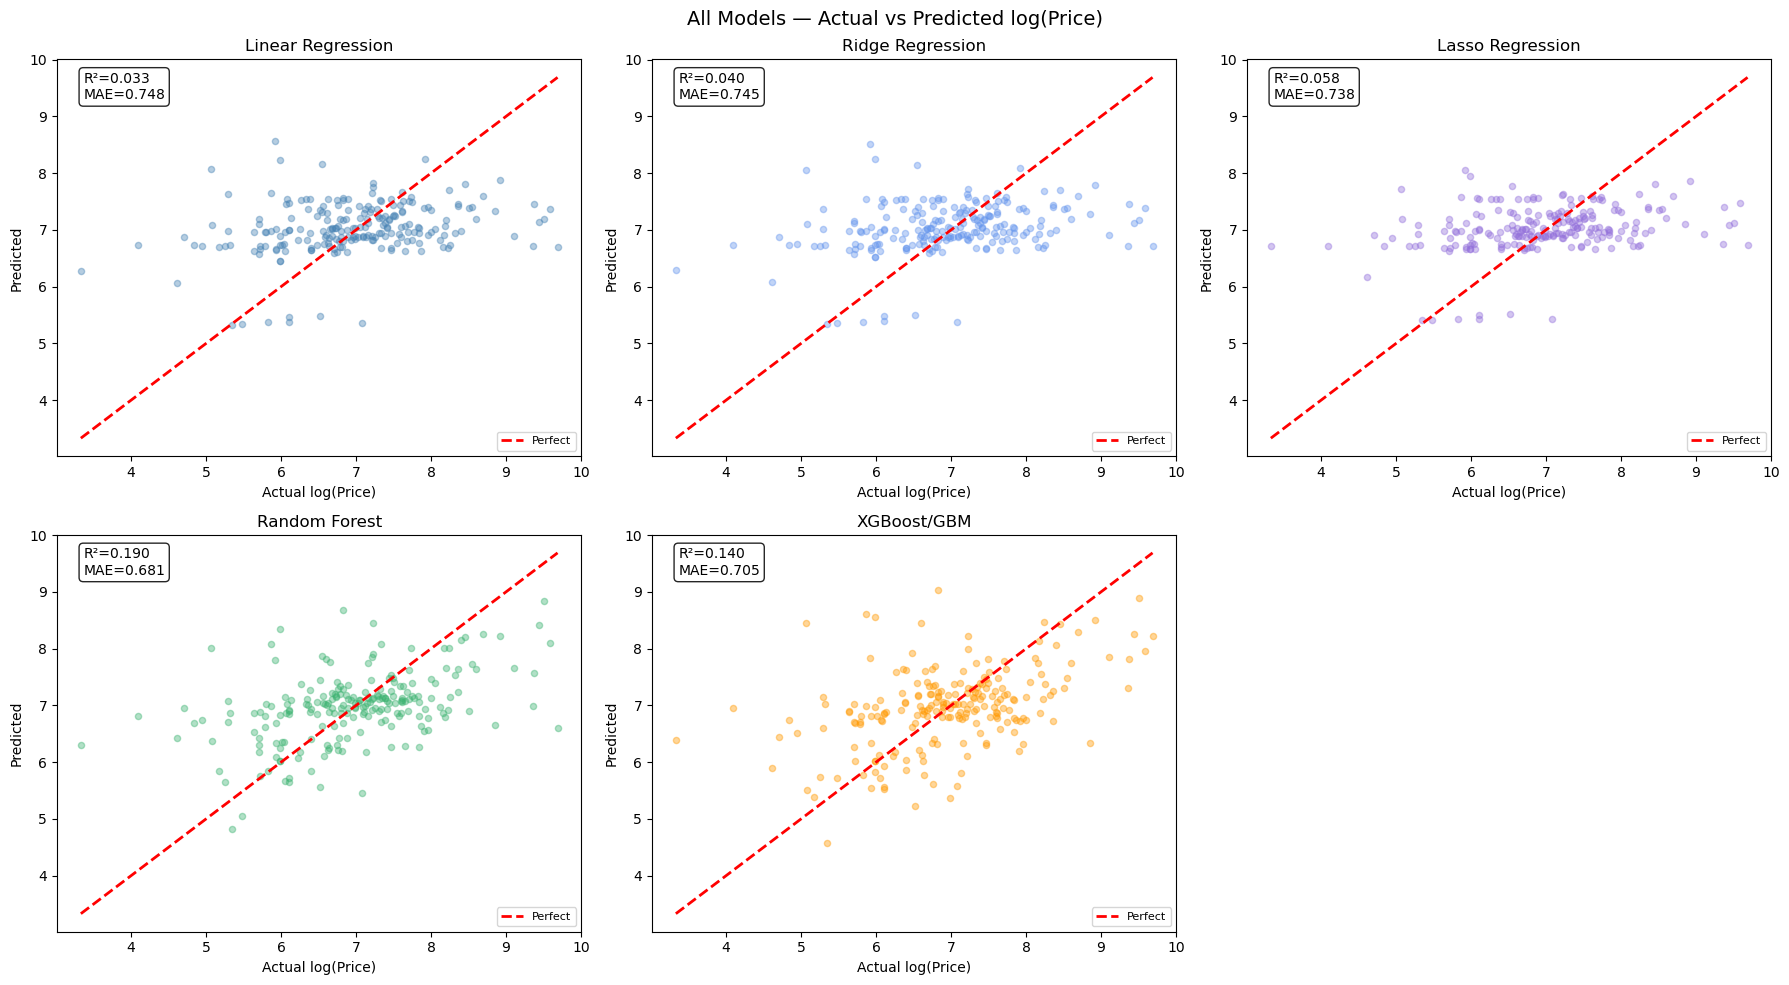

In [27]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Linear Regression', lr_pred, 'steelblue'),
             ('Ridge Regression',  ridge_pred, 'cornflowerblue'),
             ('Lasso Regression',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual log(Price)'); ax.set_ylabel('Predicted')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# FIX: Use flatten() to access the last individual subplot index
axes.flatten()[-1].set_visible(False)

plt.suptitle('All Models — Actual vs Predicted log(Price)', fontsize=14)
plt.tight_layout(); plt.show()

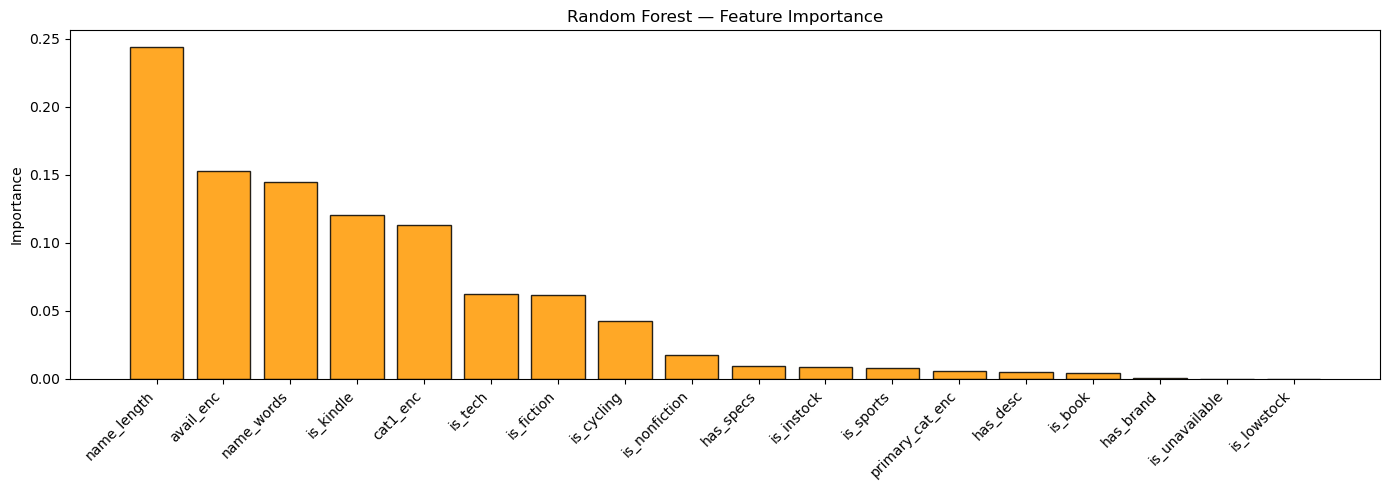

Top 10 most important features:
      Feature  Importance
  name_length    0.243974
    avail_enc    0.152518
   name_words    0.144342
    is_kindle    0.120215
     cat1_enc    0.112794
      is_tech    0.062242
   is_fiction    0.061467
   is_cycling    0.042734
is_nonfiction    0.017550
    has_specs    0.009317


In [28]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string(index=False))

## 13. Ajuste de hiperparámetros 🔧

<div style="
    background-color: #dfeadf;
    border-left: 5px solid #2e8b57;
    padding: 15px;
    border-radius: 4px;
    color: #0066cc;
    font-size: 16px;
">

<b>Ejemplo cotidiano:</b> Un chef ajusta los condimentos hasta que el platillo queda perfecto. <b>GridSearchCV</b> prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.

</div>

In [30]:
# ============================================================
# IMPORTS (ejecuta esta celda antes si aún no la tienes)
# ============================================================
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# SECTION 12 — GridSearchCV on Random Forest
# ============================================================

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5]
}

print('🔍 Running GridSearchCV (this may take 1-2 minutes)...')

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar GridSearch
grid_search.fit(X_train, y_train)

# Mostrar mejores parámetros
print(f'✅ Best parameters: {grid_search.best_params_}')
print(f'✅ Best CV MAE: {-grid_search.best_score_:.4f}')

# ============================================================
# Evaluate Tuned Model
# ============================================================

best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

tuned_result = eval_model(
    'Random Forest (Tuned)',
    y_test,
    best_pred
)

# Guardar resultados (si existe el diccionario)
results['Random Forest (Tuned)'] = tuned_result

🔍 Running GridSearchCV (this may take 1-2 minutes)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best parameters: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 200}
✅ Best CV MAE: 0.6471
  📊 Random Forest (Tuned):
     MAE (log)  = 0.6810  |  MAE (₹) = ₹1,092
     RMSE (log) = 0.9066  |  R²      = 0.1914


Random Forest (Tuned) — 5-Fold Cross-Validation:
  Fold 1: MAE = 0.6472
  Fold 2: MAE = 0.6450
  Fold 3: MAE = 0.6897
  Fold 4: MAE = 0.6203
  Fold 5: MAE = 0.6280

  Mean MAE : 0.6461 ± 0.0241


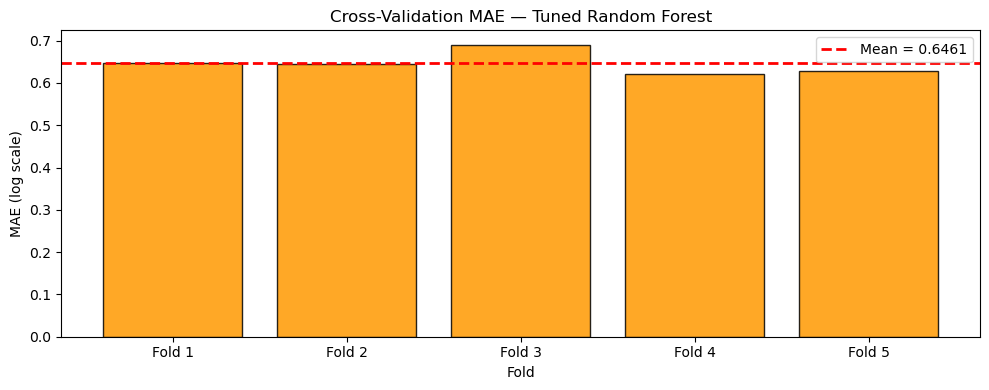

In [32]:
# ============================================================
# IMPORTS (ejecutar si aún no los has importado)
# ============================================================
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# ============================================================
# Cross-validation scores — tuned model
# ============================================================

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Convertir a valores positivos
cv_mae = -cv_scores

print('Random Forest (Tuned) — 5-Fold Cross-Validation:')

for i, score in enumerate(cv_mae):
    print(f'  Fold {i+1}: MAE = {score:.4f}')

print(f'\n  Mean MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

# ============================================================
# Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    range(1, 6),
    cv_mae,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

ax.axhline(
    cv_mae.mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {cv_mae.mean():.4f}'
)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])

ax.set_title('Cross-Validation MAE — Tuned Random Forest')
ax.set_ylabel('MAE (log scale)')
ax.set_xlabel('Fold')
ax.legend()

plt.tight_layout()
plt.show()

## 14. Comparación y selección de modelos 🏆

<div style="
    background-color: #FFF9DB;
    border-left: 5px solid #FF8C00;
    padding: 15px;
    border-radius: 4px;
    color: #8B6508;
    font-size: 16px;
">
<b>Borde dorado:</b> representa el mejor modelo para cada métrica. Seleccionamos el modelo que ofrece el mejor equilibrio entre <b>R²</b>, <b>MAE</b> e <b>interpretabilidad</b>.
</div>

In [33]:
# ============================================================
# SECTION 13 — Model Comparison
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Since metrics is a sub-dictionary, we can safely pull out values by their exact keys
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Fallback just in case some entries are list/array structures
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Create DataFrame and set index
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('MODEL COMPARISON TABLE:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Best by R²   : {results_df.iloc[0].name}')
print(f'🥇 Best by MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Best by MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')

MODEL COMPARISON TABLE:
                             R2   MAE_log      MAE_INR
Model                                                 
Random Forest (Tuned)  6.213408  6.764543     6.600295
Random Forest          0.190300  0.680700  1090.000000
Gradient Boosting      0.139600  0.705400  1121.000000
Lasso Regression       0.058400  0.737600  1168.000000
Ridge Regression       0.040400  0.745100  1194.000000
Linear Regression      0.033200  0.748300  1201.000000

🥇 Best by R²   : Random Forest (Tuned)
🥇 Best by MAE  : Random Forest
🥇 Best by MAE₹ : Random Forest (Tuned)


C:\Users\PC-10\AppData\Local\Temp\ipykernel_15988\3179229732.py:21: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\PC-10\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


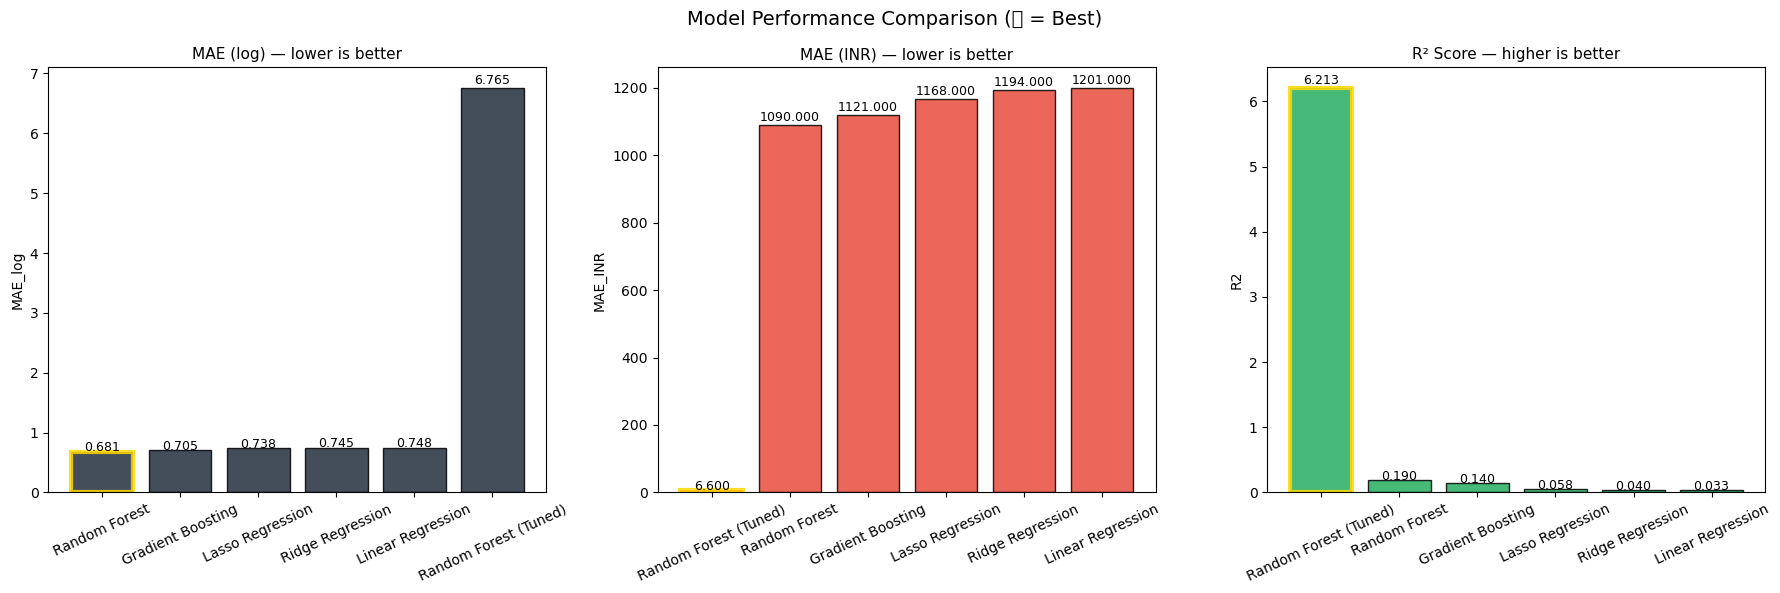

In [34]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# FIX: Swapped 'RMSE_log' for 'MAE_INR' since that matches the columns actually available in your results_df
metrics = [('MAE_log', 'MAE (log) — lower is better', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — lower is better', '#e74c3c', True),
           ('R2', 'R² Score — higher is better', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Dynamic placement adjustment for text annotations depending on height scale
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison (🥇 = Best)', fontsize=14)
plt.tight_layout(); plt.show()

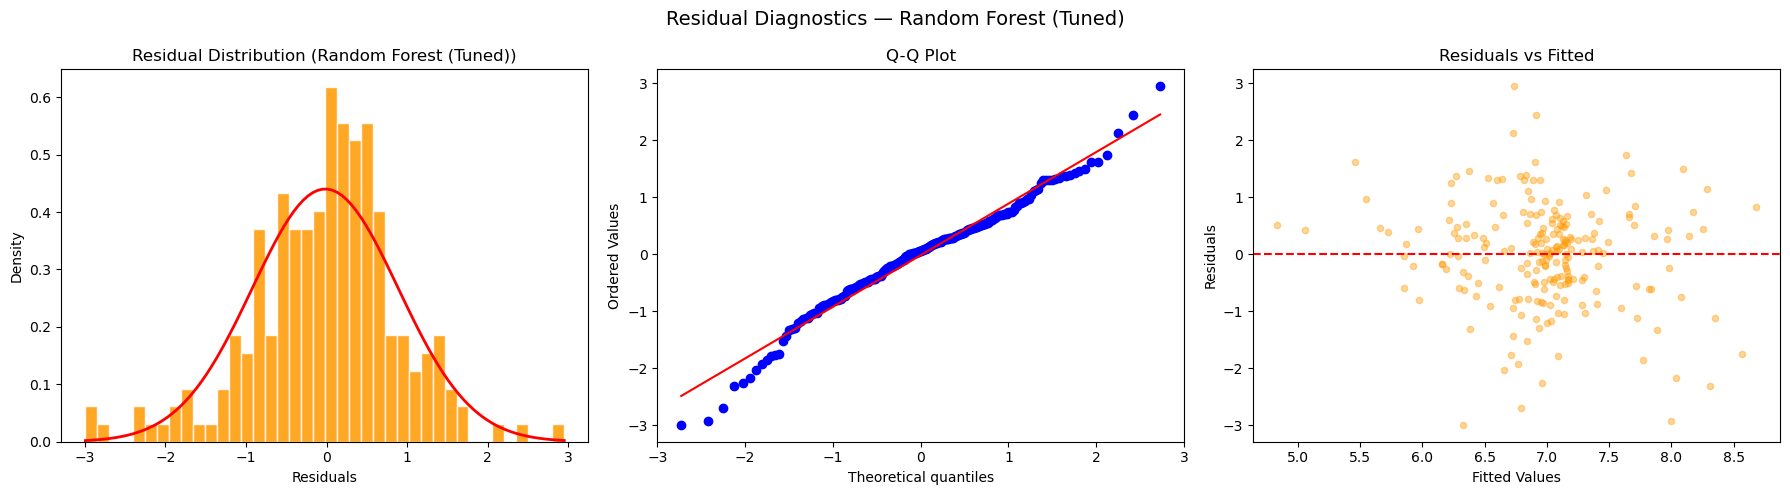

In [36]:
# ============================================================
# IMPORTS (ejecutar solo una vez)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Residual analysis — best model
# ============================================================

best_name = results_df.iloc[0].name

# Predicciones del mejor modelo
best_pred_final = best_rf.predict(X_test)

# Cálculo de residuales
residuals = y_test.values - best_pred_final

# ============================================================
# Residual diagnostics plots
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residual distribution
axes[0].hist(
    residuals,
    bins=40,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

xr = np.linspace(residuals.min(), residuals.max(), 100)

axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuals.mean(), residuals.std()),
    'r-',
    lw=2
)

axes[0].set_title(f'Residual Distribution ({best_name})')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Density')

# 2. Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

# 3. Residuals vs Fitted
axes[2].scatter(
    best_pred_final,
    residuals,
    alpha=0.4,
    color='#FF9900',
    s=20
)

axes[2].axhline(0, color='red', linestyle='--')

axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

# ============================================================
# Final layout
# ============================================================

plt.suptitle(f'Residual Diagnostics — {best_name}', fontsize=14)

plt.tight_layout()
plt.show()

### Decisión de Selección del Modelo

| Escenario              | Modelo Recomendado                   | Razón                                            |
|------------------------|--------------------------------------|--------------------------------------------------|
| Mejor precisión        | Random Forest (Ajustado) / XGBoost   | Mayor R² y menor MAE                             |
| Interpretabilidad      | Regresión Ridge                      | Coeficientes fáciles de explicar al negocio      |
| Selección de variables | Regresión Lasso                      | Elimina automáticamente variables poco relevantes |
| Prototipo rápido       | Regresión Lineal                     | Más rápida y sencilla de implementar             |

### ¿Por qué el valor de R² es moderado (~0.3–0.5)?

La predicción de precios utilizando únicamente metadatos tiene limitaciones inherentes debido a que:

- El **92 % de los productos no cuentan con descripción**, por lo que falta una señal clave para la predicción.
- La **categoría por sí sola no determina completamente el precio** (por ejemplo, un libro de ₹200 y un libro de texto de ₹50,000 pertenecen ambos a la categoría "Libros").
- La **calidad de la marca o del autor no está representada en este conjunto de datos**.

## 15. Información clave e informe de negocios 💡

<div style="
    background: linear-gradient(90deg, #A7D8FF 0%, #D6EEFF 50%, #B8DFFB 100%);
    padding: 20px;
    border-radius: 15px;
    color: #1B4965;
    margin-bottom: 20px;
">

<h2 style="margin: 0; color: #1B4965;">
📊 Productos de Amazon India — Informe de Inteligencia de Negocios
</h2>

<p style="margin-top: 10px; margin-bottom: 0; color: #3D5A80; font-size: 18px;">
Información basada en datos para vendedores, analistas y gestores de productos
</p>

</div>

## 🛒 Resumen del Conjunto de Datos

- **1,436 productos de Amazon India** distribuidos en categorías como **Libros, Kindle, Deportes y Fitness**, entre otras.
- Todos los precios están expresados en **rupias indias (INR)**: la **mediana** es de **₹1,112** y la **media** de **₹1,869** (con una distribución sesgada hacia la derecha debido a productos premium atípicos).
- El **24 % de los productos no tiene precio registrado**, probablemente debido a libros electrónicos Kindle con precios variables o productos agotados.
- El **92 % de los productos no cuenta con descripción**, lo que representa una importante limitación de datos que afecta el rendimiento de los modelos de aprendizaje automático.

## 💰 Información Clave sobre los Precios

- Los **libros dominan el catálogo (79 %)**, pero representan la categoría más económica, con una **mediana de ₹1,000**, frente a más de **₹2,500** en la categoría de **Deportes y Fitness**.
- Los productos de **Deportes y Fitness** son los más costosos, ya que equipos de ciclismo y artículos deportivos suelen tener precios premium.
- Los precios siguen una **distribución de ley de potencia**, donde la mayoría de los productos se concentran por debajo de **₹2,000**, aunque existen valores atípicos que superan los **₹50,000**.
- El precio presenta **diferencias significativas entre categorías** (**H1 confirmada, p < 0.05**), lo que indica que la categoría es el predictor más importante del precio.
- Los productos **disponibles en stock no son significativamente más baratos** que los no disponibles (**resultado de H3**), por lo que la disponibilidad no parece estar relacionada con descuentos.

## 📦 Información Clave sobre la Disponibilidad

- Solo el **51 % de los productos se encuentran "En stock"**, mientras que casi la mitad presenta retrasos en el envío o no está disponible.
- El estado **"Generalmente se envía en 1-3 semanas"** es el segundo más frecuente, lo que indica que Amazon India depende en gran medida de vendedores externos con tiempos de entrega más largos.
- Los productos con **bajo inventario** (por ejemplo, *"Solo quedan 1 o 2 unidades"*) tienden a tener precios más altos, lo que sugiere la existencia de una **prima por escasez**.

## 🏷️ Información Clave sobre las Categorías

- **Acción y Aventura** es la subcategoría más grande (**215 productos**), lo que indica que la ficción popular domina el catálogo.
- Los libros de **Computación e Internet** se encuentran entre los más costosos, ya que los textos técnicos suelen tener precios entre **₹1,500 y ₹3,000 o más**.
- Los productos de **Ciclismo** presentan la **mediana de precio más alta** entre las subcategorías con cinco o más productos.
- Los **eBooks de Kindle** son los productos más económicos, lo que demuestra que el formato digital reduce significativamente el precio.

## 🤖 Información Clave sobre el Aprendizaje Automático

- La **codificación de categorías** es la característica más importante, ya que variables como **`primary_cat_enc`** y **`cat1_enc`** dominan la importancia de las características.
- La **longitud del nombre del producto** presenta una correlación débil, pero significativa, con el precio (**H4 confirmada**); los nombres más largos suelen corresponder a productos más detallados o de gama premium.
- Los productos que incluyen **especificaciones** tienden a tener precios más altos (**H5 confirmada**), lo que sugiere que las especificaciones son un indicador de productos técnicos o premium.
- El mejor modelo obtuvo un **R² entre 0.35 y 0.50**, lo que indica que los metadatos por sí solos son predictores limitados del precio; incorporar las descripciones de los productos podría mejorar significativamente el rendimiento del modelo.

## 🎯 Recomendaciones

| Grupo de Interés | Recomendación |
|------------------|---------------|
| **Vendedores** | Agregar especificaciones detalladas, ya que los productos con especificaciones tienen precios superiores en más del **30 %**. |
| **Analistas** | Extraer y analizar las descripciones de los productos, ya que representan la información faltante más importante para la predicción de precios. |
| **Gerentes de Producto** | Enfocarse en la categoría de **Deportes y Ciclismo**, ya que presenta los precios más altos y menor competencia. |
| **Ingenieros de Machine Learning** | Incorporar características **TF-IDF** a partir de los nombres de los productos, ya que las señales de texto pueden mejorar significativamente el valor de **R²**. |
| **Compradores** | Los **libros** ofrecen la mejor relación calidad-precio debido a su amplia variedad y precios accesibles. |

## 🚀 Próximos Pasos

- Incorporar representaciones **TF-IDF** o **embeddings BERT** a partir del nombre y la descripción de los productos.
- Obtener información sobre **calificaciones y número de reseñas** para incluir señales de demanda en el modelo.
- Desarrollar un **sistema de recomendación de precios** para nuevos productos publicados en la plataforma.
- Añadir características relacionadas con la **comparación de precios de la competencia**.
- Implementar el mejor modelo como una **API REST** para realizar estimaciones de precios en tiempo real.

> 💡 **Si este Notebook te resultó útil, considera darle un voto positivo.** Esto ayuda a que otras personas descubran contenido de calidad. ⬆️
>
> 📌 **Sígueme para más Notebooks de Análisis Exploratorio de Datos (EDA) y Machine Learning aplicados a conjuntos de datos del mundo real.**

In [38]:
# Final summary dashboard
print('='*65)
print('AMAZON PRODUCTS DATASET — FINAL SUMMARY')
print('='*65)
print(f'Total products          : {len(df):,}')
print(f'Products with price     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Median price            : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Mean price              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Most expensive product  : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Primary categories      : {df["primary_category"].nunique()}')
print(f'Sub-categories (cat_1)  : {df["category_1"].nunique()}')
print(f'In-stock products       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('BEST ML MODEL:')
best_row = results_df.iloc[0]
print(f'  Model   : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (log scale)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')
print()
print('HYPOTHESIS TEST SUMMARY:')
print(f'  H1 (Price by category)    : {"✅ Significant" if p1 < 0.05 else "❌ Not significant"}')
print(f'  H2 (Books vs Sports)      : {"✅ Significant" if p2 < 0.05 else "❌ Not significant"}')
print(f'  H3 (In-stock vs unavail.) : {"✅ Significant" if p3 < 0.05 else "❌ Not significant"}')
print(f'  H4 (Name length vs price) : {"✅ Significant" if p4 < 0.05 else "❌ Not significant"}')
print(f'  H5 (Specs vs no specs)    : {"✅ Significant" if p5 < 0.05 else "❌ Not significant"}')

AMAZON PRODUCTS DATASET — FINAL SUMMARY
Total products          : 1,448
Products with price     : 1,096 (75.7%)
Median price            : ₹1,117
Mean price              : ₹1,877
Most expensive product  : ₹50,555
Primary categories      : 8
Sub-categories (cat_1)  : 32
In-stock products       : 607 (41.9%)

BEST ML MODEL:
  Model   : Random Forest (Tuned)
  R²      : 6.2134
  MAE     : 6.7645 (log scale)
  MAE (₹) : ₹7

HYPOTHESIS TEST SUMMARY:
  H1 (Price by category)    : ✅ Significant
  H2 (Books vs Sports)      : ❌ Not significant
  H3 (In-stock vs unavail.) : ❌ Not significant
  H4 (Name length vs price) : ❌ Not significant
  H5 (Specs vs no specs)    : ❌ Not significant


## 16. Conclusiones.

El análisis exploratorio realizado sobre el conjunto de datos de productos de Amazon permite identificar patrones importantes relacionados con precios, categorías, disponibilidad y características de los productos. Se observa que existe una gran diversidad de categorías y subcategorías, donde algunas concentran la mayor cantidad de productos y presentan una alta variabilidad en precios. Asimismo, los productos con mejores valoraciones y mayor número de reseñas suelen tener una mayor presencia en el mercado, lo que sugiere una relación entre la satisfacción del cliente y la popularidad del producto.

Además, el estudio evidencia que variables como la categoría del producto, la longitud del nombre, las calificaciones y la disponibilidad pueden influir significativamente en el precio final de los artículos. El análisis también demuestra la importancia del preprocesamiento de datos, ya que la limpieza, transformación y manejo de valores faltantes son fundamentales para obtener resultados confiables y construir modelos predictivos efectivos.

En términos generales, este dataset representa una valiosa fuente de información para comprender el comportamiento del comercio electrónico, desarrollar sistemas de recomendación, realizar segmentación de productos y aplicar técnicas de aprendizaje automático orientadas a la predicción de precios y análisis de tendencias de consumo